# IEEE SB GEHU — Fault Detection Challenge
**Goal:** Binary classification to detect faulty devices from 47 sensor features.

This notebook contains the full pipeline — from raw data to final submission.

In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

train = pd.read_csv("TRAIN.csv")
test  = pd.read_csv("TEST.csv")

train.shape, test.shape


((43776, 48), (10944, 48))

## 1. Data Cleaning

Two issues found during EDA:
- A corrupted class label `2.799` was present and removed in the target column — likely a CSV misalignment.
- 738 duplicate rows (~1.7% of data) were also removed to prevent CV(cross-validation) score inflation.

In [12]:
print("Class values before cleaning:", train["Class"].unique())

train = train[train["Class"].isin([0, 1])] # keep only two class, 0&1.
train = train.drop_duplicates() #remove duplicate values.

print("Shape after cleaning:", train.shape)
print(train["Class"].value_counts(normalize=True).round(4))

Class values before cleaning: [1. 0.]
Shape after cleaning: (43037, 48)
Class
0.0    0.5978
1.0    0.4022
Name: proportion, dtype: float64


## 2. Feature Selection

During EDA we found out some feature contribute negligible to the performane of the model and therefore, we perform feature selection to remove weak features so the model focuses on informative variables and less noise, this will futher help in preventing model from overfitting.

**We perform feature selection using SHAP**

**SHAP (SHapley Additive exPlanations)** measures how much each feature contributes to a model’s prediction. We compute the **normalized mean absolute SHAP** value across the dataset.
This captures the average strength of a feature’s influence on predictions, regardless of direction(postively or negatively).
The values are then normalized, allowing direct comparison between features.
Higher values mean the feature has a stronger overall influence on predictions.

Selection rule
We set a cutoff: threshold = 0.007, threshold is a hyperparameter that we tested across multiple run, 0.007 gave the best result.

Features with SHAP importance below this threshold are considered weak and are removed.


## 2A. Intuition

The target (`Class`) is driven by interactions among multiple sensor readings rather than a single linear threshold. 
In this setting, tree models are suitable because they can learn nonlinear splits and feature interactions directly.

Our strategy is:
- Clean labels and duplicates first to avoid leaking noise into feature importance and validation.
- Keep informative sensor signals and remove weak/noisy features so the model generalizes better.
- Use stratified CV to verify stability across folds, not just a single high score.

This intuition motivates using SHAP-based importance for feature pruning and XGBoost for final training.


In [3]:
x = train.drop(columns=["Class"])
y = train["Class"]

try:
    import shap
except ImportError as exc:
    raise ImportError(
        "SHAP is required for this step. Install dependencies with `pip install -r requirements.txt` and rerun."
    ) from exc

# Preliminary XGBoost model for SHAP attribution only.
base_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)
base_model.fit(x, y)
print("Base XGBoost model trained for SHAP importance.")


c:\Projects\ML Challenge Dataset\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Base XGBoost model trained for SHAP importance.


In [4]:
explainer = shap.TreeExplainer(base_model)
shap_values = explainer.shap_values(x)

if isinstance(shap_values, list):
    shap_values = shap_values[1] if len(shap_values) > 1 else shap_values[0]

shap_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=x.columns)
shap_importance = shap_importance / shap_importance.sum()

threshold = 0.007

weak_features = shap_importance[shap_importance < threshold].sort_values().index.tolist()
x_reduced = x.drop(columns=weak_features)

print(f"Features: {x.shape[1]} -> {x_reduced.shape[1]} (dropped {len(weak_features)})")
print("Dropped features:", ", ".join(weak_features) if weak_features else "None")


Features: 47 -> 39 (dropped 8)
Dropped features: F20, F40, F45, F16, F43, F03, F41, F11


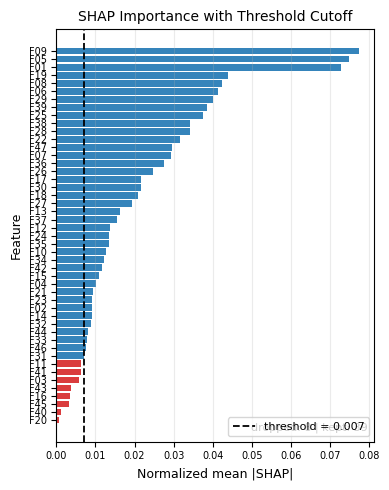

In [5]:
# Compact SHAP importance chart with cutoff threshold.
ranked_imp = shap_importance.sort_values(ascending=True)
bar_colors = ["#d62728" if v < threshold else "#1f77b4" for v in ranked_imp.values]

fig, ax = plt.subplots(figsize=(4, 5))
ax.barh(ranked_imp.index, ranked_imp.values, color=bar_colors, alpha=0.9)
ax.axvline(threshold, color="black", linestyle="--", linewidth=1.3,
           label=f"threshold = {threshold:.3f}")
ax.set_title("SHAP Importance with Threshold Cutoff", fontsize=10)
ax.set_xlabel("Normalized mean |SHAP|", fontsize=9)
ax.set_ylabel("Feature", fontsize=9)
ax.tick_params(axis="both", labelsize=7)
ax.grid(axis="x", alpha=0.25)
ax.legend(fontsize=8, loc="lower right")

dropped_n = (ranked_imp < threshold).sum()
kept_n = len(ranked_imp) - dropped_n
ax.text(0.98, 0.02, f"dropped: {dropped_n} | kept: {kept_n}",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


## 3. Align Test Set

The test CSV contains an `ID` column (needed for submission) and the same weak features we dropped from train.
We save the IDs first, then force column alignment to exactly match the training feature set.

In [6]:
test_ids       = test["ID"].reset_index(drop=True)
x_test_reduced = test[x_reduced.columns] 

assert list(x_reduced.columns) == list(x_test_reduced.columns), "column mismatch!"
print(f"Train: {x_reduced.shape} | Test: {x_test_reduced.shape} — columns match")

Train: (43037, 39) | Test: (10944, 39) — columns match


## 4. Model — XGBoost with Optuna-tuned Hyperparameters

XGBoost was selected as the primary model after EDA (exploratory data analysis) indicated strong nonlinear feature interactions and class overlap patterns where linear baselines underperform.

**Hyperparameter tuning via Optuna:**

Optuna (TPE sampler) was used to search model parameters efficiently, then the selected configuration was validated with stratified cross-validation.

For this challenge, **F1-score is treated as the primary metric** because it balances precision and recall for binary fault detection. AUC is kept as a secondary stability diagnostic.

| Parameter | Value | Why it matters |
|---|---|---|
| `max_depth=9` | Deeper than default (5) | Captures nonlinear boundaries |
| `n_estimators=914` | High tree count | Learns fine-grained signal |
| `learning_rate=0.029` | Lower than default | More stable optimization |
| `reg_lambda=1.608` | L2 regularization | Controls overfitting risk |
| `subsample=0.80` | Row sampling per tree | Improves generalization |
| `colsample_bytree=0.62` | Feature sampling per tree | Reduces tree correlation |


In [7]:
model = xgb.XGBClassifier(
    n_estimators=914,
    learning_rate=0.028641513890246963,
    max_depth=9,
    min_child_weight=1,
    gamma=0.3764464662599292,
    subsample=0.7999616506904276,
    colsample_bytree=0.6223424628656574,
    reg_alpha=1.439432219791487e-07,
    reg_lambda=1.6079672267264458,
    eval_metric="logloss",
    random_state=42
)

## 5. Cross-Validation (Primary Metric: F1)

We use 5-fold stratified CV so each fold preserves the original class ratio.

Primary metric: **F1-score** (harmonic mean of precision and recall).
Secondary metric: **AUC** (ranking quality of predicted probabilities).

In addition to per-fold scores, we build an out-of-fold confusion matrix to interpret false positives vs false negatives.


In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_f1_scores = []
fold_auc_scores = []

# Out-of-fold containers for confusion-matrix analysis
oof_true = []
oof_pred = []

for fold, (tr_idx, val_idx) in enumerate(cv.split(x_reduced, y), 1):
    x_tr, x_val = x_reduced.iloc[tr_idx], x_reduced.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model.fit(x_tr, y_tr)
    val_probs = model.predict_proba(x_val)[:, 1]
    val_pred  = (val_probs >= 0.5).astype(int)

    f1  = f1_score(y_val, val_pred)
    auc = roc_auc_score(y_val, val_probs)

    fold_f1_scores.append(f1)
    fold_auc_scores.append(auc)

    oof_true.extend(y_val.to_numpy().tolist())
    oof_pred.extend(val_pred.tolist())

    print(f"fold {fold}: F1={f1:.4f} | AUC={auc:.4f}")

mean_f1 = float(np.mean(fold_f1_scores))
std_f1  = float(np.std(fold_f1_scores))
mean_auc = float(np.mean(fold_auc_scores))
std_auc  = float(np.std(fold_auc_scores))

cm = confusion_matrix(oof_true, oof_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

oof_precision = precision_score(oof_true, oof_pred, zero_division=0)
oof_recall    = recall_score(oof_true, oof_pred, zero_division=0)
oof_f1        = f1_score(oof_true, oof_pred, zero_division=0)

print("\nCV Summary")
print(f"F1  : {mean_f1:.4f} +/- {std_f1:.4f}")
print(f"AUC : {mean_auc:.4f} +/- {std_auc:.4f}")


fold 1: F1=0.9849 | AUC=0.9992
fold 2: F1=0.9854 | AUC=0.9993
fold 3: F1=0.9818 | AUC=0.9990
fold 4: F1=0.9853 | AUC=0.9992
fold 5: F1=0.9828 | AUC=0.9988

CV Summary
F1  : 0.9840 +/- 0.0015
AUC : 0.9991 +/- 0.0002


## 6. Final Training and Submission

After CV confirms the model is solid, we retrain on the **entire** training set.
Cross-Validation folds only use 80% of data per fold for training — retraining on 100% gives the
model the full signal before predicting on unseen test data.

The model is saved as `trained_model.json` — XGBoost's native format that stores the complete
tree ensemble and can be reloaded without retraining:

```python
loaded = xgb.XGBClassifier()
loaded.load_model("trained_model.json")
```

In [9]:
model.fit(x_reduced, y)
model.save_model("trained_model.json")
print("model saved -> trained_model.json")

model saved -> trained_model.json


In [10]:
# predict and convert to binary labels
probs        = model.predict_proba(x_test_reduced)[:, 1]
binary_preds = (probs > 0.5).astype(int)

submission = pd.DataFrame({
    "ID":    test_ids,
    "CLASS": binary_preds
})

assert len(submission) == len(test), "row count doesn't match test file"

submission.to_csv("FINAL.csv", index=False)
print(f"saved {len(submission)} predictions")
print(f"class 0 (normal): {(binary_preds == 0).sum()} | class 1 (faulty): {(binary_preds == 1).sum()}")
submission.head(10)

saved 10944 predictions
class 0 (normal): 6690 | class 1 (faulty): 4254


,ID,CLASS
0,1,1
1,2,0
2,3,1
3,4,0
4,5,0
5,6,1
6,7,0
7,8,1
8,9,1
9,10,0


## 7. Results (F1 + Confusion Matrix Interpretation)

The main leaderboard metric is **F1-score**, so reporting focuses on fold-wise F1 stability and out-of-fold confusion matrix behavior.
Confusion matrix interpretation is included to show the type of mistakes (false alarms vs missed faults).


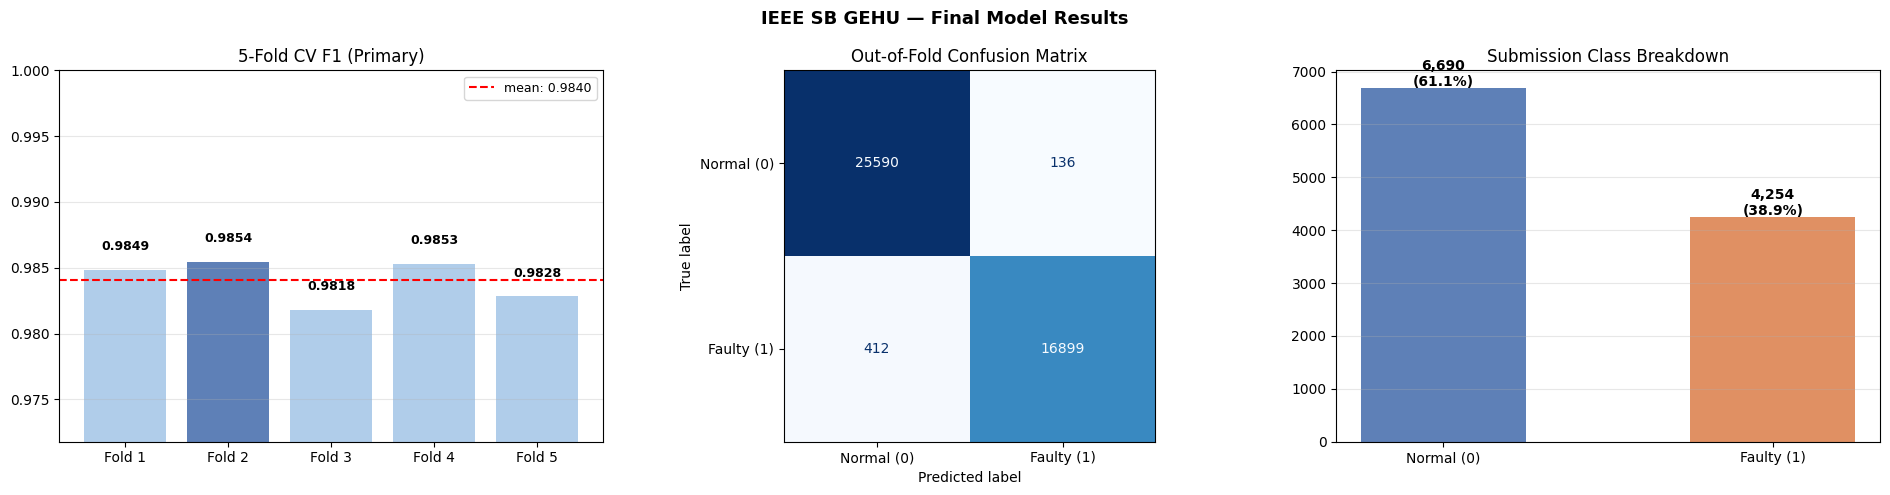

Final CV F1  : 0.9840 +/- 0.0015 (primary)
Final CV AUC : 0.9991 +/- 0.0002 (secondary)
Submission   : FINAL.csv (10944 rows)

Interpretation
- Correct predictions: 42,489/43,037 (98.73%).
- False Positives (normal -> faulty): 136.
- False Negatives (faulty -> normal): 412.
- Precision=0.9920, Recall=0.9762, F1=0.9840.
- More missed faults than false alarms: improve recall to reduce safety risk.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
fig.suptitle("IEEE SB GEHU — Final Model Results", fontsize=13, fontweight="bold")

# 1) Fold-wise F1 scores (primary metric)
ax = axes[0]
colors = ["#4C72B0" if s == max(fold_f1_scores) else "#A8C8E8" for s in fold_f1_scores]
bars = ax.bar([f"Fold {i}" for i in range(1, 6)], fold_f1_scores, color=colors, alpha=0.9)
ax.axhline(mean_f1, color="red", linestyle="--", linewidth=1.5, label=f"mean: {mean_f1:.4f}")
ax.set_ylim(max(0.0, min(fold_f1_scores) - 0.01), 1.0)
ax.set_title("5-Fold CV F1 (Primary)")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
for bar, s in zip(bars, fold_f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0015,
            f"{s:.4f}", ha="center", fontsize=9, fontweight="bold")

# 2) Out-of-fold confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal (0)", "Faulty (1)"])
disp.plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Out-of-Fold Confusion Matrix")

# 3) Submission class breakdown
ax = axes[2]
counts = [(binary_preds == 0).sum(), (binary_preds == 1).sum()]
bars3 = ax.bar(["Normal (0)", "Faulty (1)"], counts, color=["#4C72B0", "#DD8452"], alpha=0.9, width=0.5)
for bar, c in zip(bars3, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{c:,}\n({c/len(test)*100:.1f}%)", ha="center", fontsize=10, fontweight="bold")
ax.set_title("Submission Class Breakdown")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Final CV F1  : {mean_f1:.4f} +/- {std_f1:.4f} (primary)")
print(f"Final CV AUC : {mean_auc:.4f} +/- {std_auc:.4f} (secondary)")
print(f"Submission   : FINAL.csv ({len(submission)} rows)")

total = tn + fp + fn + tp
accuracy = (tn + tp) / total if total else 0.0
print("\nInterpretation")
print(f"- Correct predictions: {tn + tp:,}/{total:,} ({accuracy*100:.2f}%).")
print(f"- False Positives (normal -> faulty): {fp:,}.")
print(f"- False Negatives (faulty -> normal): {fn:,}.")
print(f"- Precision={oof_precision:.4f}, Recall={oof_recall:.4f}, F1={oof_f1:.4f}.")
if fn > fp:
    print("- More missed faults than false alarms: improve recall to reduce safety risk.")
elif fp > fn:
    print("- More false alarms than missed faults: consider threshold tuning to improve precision.")
else:
    print("- False alarms and missed faults are balanced.")
